In [1]:
# Cell 0: setup
from google.colab import drive; drive.mount('/content/drive')
!pip install -q evidently

import pandas as pd, numpy as np
PROJECT = "/content/drive/MyDrive/churn-prediction-system"

df = pd.read_parquet(f"{PROJECT}/data/processed/features_v2.parquet")
df = df[df["has_txn"] == 1].copy()
print("Loaded:", df.shape)
print("tenure_days range:", df["tenure_days"].min(), "→", df["tenure_days"].max())

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.8/581.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.1 MB/s eta 0:00:00
Loaded: (480853, 37)
tenure_days range: 0.0 → 4753.0


In [3]:
import evidently
print("Evidently version:", evidently.__version__)

Evidently version: 0.7.21


In [4]:
# Cell 1: temporal cohorts (reference = older users, current = newer users)
FEATURE_COLS = [
    "txn_count","cancel_count","autorenew_share","last_plan_days","last_actual_paid",
    "last_list_price","last_discount","last_auto_renew","last_is_cancel",
    "secs_total","active_days","completion_ratio","tenure_days",
    "seq_days_since_last","seq_cancel_last3","seq_price_slope","seq_gap_widening","seq_mean_gap_days",
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

split_pt = df["tenure_days"].median()
reference = df[df["tenure_days"] >  split_pt][FEATURE_COLS].copy()   # established users
current   = df[df["tenure_days"] <= split_pt][FEATURE_COLS].copy()   # newer users

print(f"Split at tenure = {split_pt:.0f} days")
print(f"Reference (established): {reference.shape}")
print(f"Current (newer):        {current.shape}")

Split at tenure = 1048 days
Reference (established): (212363, 18)
Current (newer):        (212614, 18)


In [5]:
# Cell 2: real temporal drift report
import os
os.makedirs(f"{PROJECT}/reports/drift", exist_ok=True)

from evidently import Report
from evidently.presets import DataDriftPreset

report = Report(metrics=[DataDriftPreset()])
result = report.run(reference_data=reference, current_data=current)
result.save_html(f"{PROJECT}/reports/drift/temporal_drift.html")
print("✅ Saved temporal_drift.html")

# Also extract a summary we can use in the UI (not just the HTML)
summary = result.dict()
print("\nReport keys:", list(summary.keys())[:5])

✅ Saved temporal_drift.html

Report keys: ['metrics', 'tests']


In [8]:
# Cell 2b: extract drift findings from the report
summary = result.dict()

# Navigate the structure to find drift results (0.7.x nests them under 'metrics')
import json
metrics = summary.get("metrics", [])
print("Number of metric results:", len(metrics))

# Print the drift-related metrics readably
for m in metrics:
    mid = m.get("metric_id", m.get("metric", ""))
    if "drift" in str(mid).lower() or "Drift" in str(mid):
        val = m.get("value", m.get("result", ""))
        print(f"\n{mid}:")
        print(f"  {json.dumps(val, indent=2)[:400]}")

Number of metric results: 19


In [9]:
# Inspect the actual structure — no filtering, just show what's there
import json
summary = result.dict()
metrics = summary.get("metrics", [])

# Show the first metric fully, and all metric IDs
print("=== First metric (full) ===")
print(json.dumps(metrics[0], indent=2)[:800])

print("\n=== All metric IDs / keys ===")
for i, m in enumerate(metrics):
    print(f"{i}: keys={list(m.keys())} | id={m.get('metric_id', m.get('id', '?'))}")

=== First metric (full) ===
{
  "id": "15e89f895b482f9b84ba7274ed18a106",
  "metric_name": "DriftedColumnsCount(drift_share=0.5)",
  "config": {
    "type": "evidently:metric_v2:DriftedColumnsCount",
    "drift_share": 0.5
  },
  "value": {
    "count": 9.0,
    "share": 0.5
  }
}

=== All metric IDs / keys ===
0: keys=['id', 'metric_name', 'config', 'value'] | id=15e89f895b482f9b84ba7274ed18a106
1: keys=['id', 'metric_name', 'config', 'value'] | id=3420b3d82c94658c778a0edabf85b248
2: keys=['id', 'metric_name', 'config', 'value'] | id=f50db12ec652bcd465216d33bd375e34
3: keys=['id', 'metric_name', 'config', 'value'] | id=a0f0068b0a9a24f261d54b7144c6caff
4: keys=['id', 'metric_name', 'config', 'value'] | id=3ec994ec2f781ca2434e3be7e05f119e
5: keys=['id', 'metric_name', 'config', 'value'] | id=ba3e7d4f553cadf2f66d2e96bbd221c5
6: keys=['id', 'metric_name', 'config', 'value'] | id=b1381869953f2d00f3a0d29f3f01b619
7: keys=['id', 'metric_name', 'config', 'value'] | id=0afdec430939ef14596e3270

In [10]:
# Simpler: Evidently often has a direct summary dict
try:
    print(json.dumps(result.dict()["metrics"][0], indent=2)[:600])
except Exception as e:
    print("structure differs:", e)

# Some 0.7.x versions expose a datadrift summary via as_dict or specific accessor
# Show top-level result attributes available
print("\nResult attributes:", [a for a in dir(result) if not a.startswith("_")][:20])

{
  "id": "15e89f895b482f9b84ba7274ed18a106",
  "metric_name": "DriftedColumnsCount(drift_share=0.5)",
  "config": {
    "type": "evidently:metric_v2:DriftedColumnsCount",
    "drift_share": 0.5
  },
  "value": {
    "count": 9.0,
    "share": 0.5
  }
}

Result attributes: ['context', 'dict', 'dump_dict', 'dumps', 'get_html_str', 'get_name', 'json', 'load', 'load_dict', 'load_model', 'loads', 'metric_results', 'render_only_fingerprint', 'report', 'run', 'save_html', 'save_json', 'set_name', 'tests_results', 'to_snapshot_model']


In [11]:
# Cell 3: synthetic drift validation
drifted = reference.copy()

# Inject deliberate, realistic shifts:
drifted["seq_days_since_last"] = drifted["seq_days_since_last"] + 45      # engagement gap widens
drifted["autorenew_share"]     = drifted["autorenew_share"] * 0.5        # auto-renew adoption drops
drifted["last_actual_paid"]    = drifted["last_actual_paid"] * 1.3       # price change
# leave other features unchanged — Evidently should flag ONLY the 3 above

report_syn = Report(metrics=[DataDriftPreset()])
result_syn = report_syn.run(reference_data=reference, current_data=drifted)
result_syn.save_html(f"{PROJECT}/reports/drift/synthetic_drift.html")
print("✅ Saved synthetic_drift.html")
print("Injected drift into: seq_days_since_last (+45), autorenew_share (×0.5), last_actual_paid (×1.3)")
print("Expectation: Evidently flags these 3 as drifted, most others as stable.")

✅ Saved synthetic_drift.html
Injected drift into: seq_days_since_last (+45), autorenew_share (×0.5), last_actual_paid (×1.3)
Expectation: Evidently flags these 3 as drifted, most others as stable.


In [13]:
# Extract drift summaries — handles both dict and scalar 'value'
import json

def extract_drift(result, label):
    d = result.dict()
    metrics = d.get("metrics", [])
    out = {"label": label, "drifted_count": None, "total": 18, "share": None, "drifted_features": []}
    for m in metrics:
        name = m.get("metric_name", "")
        val = m.get("value", {})
        if "DriftedColumnsCount" in name:
            if isinstance(val, dict):
                out["drifted_count"] = val.get("count")
                out["share"] = val.get("share")
        elif "ValueDrift" in name or "ColumnDrift" in name:
            col = name.split("column=")[-1].rstrip(")") if "column=" in name else name
            # value may be a scalar drift score or a dict
            if isinstance(val, dict):
                score = val.get("drift_score", val.get("drift_detected"))
            else:
                score = float(val)   # bare drift score
            out["drifted_features"].append({"feature": col, "drift_score": round(float(score), 4) if score is not None else None})
    return out

temporal = extract_drift(result, "temporal (older vs newer users)")
synthetic = extract_drift(result_syn, "synthetic (injected drift)")

print("=== TEMPORAL ===")
print(f"Drifted: {temporal['drifted_count']}/18 ({temporal['share']:.0%})" if temporal['share'] else "count only")
for f in temporal["drifted_features"]:
    print(f"  {f['feature']}: {f['drift_score']}")

print("\n=== SYNTHETIC ===")
print(f"Drifted: {synthetic['drifted_count']}/18")
for f in synthetic["drifted_features"]:
    print(f"  {f['feature']}: {f['drift_score']}")

=== TEMPORAL ===
Drifted: 9.0/18 (50%)
  txn_count,method=Wasserstein distance (normed),threshold=0.1: 0.1465
  cancel_count,method=Jensen-Shannon distance,threshold=0.1: 0.0147
  autorenew_share,method=Wasserstein distance (normed),threshold=0.1: 0.1263
  last_plan_days,method=Wasserstein distance (normed),threshold=0.1: 0.0255
  last_actual_paid,method=Wasserstein distance (normed),threshold=0.1: 0.128
  last_list_price,method=Wasserstein distance (normed),threshold=0.1: 0.1277
  last_discount,method=Wasserstein distance (normed),threshold=0.1: 0.0147
  last_auto_renew,method=Jensen-Shannon distance,threshold=0.1: 0.0399
  last_is_cancel,method=Jensen-Shannon distance,threshold=0.1: 0.0039
  secs_total,method=Wasserstein distance (normed),threshold=0.1: 0.1131
  active_days,method=Wasserstein distance (normed),threshold=0.1: 0.1559
  completion_ratio,method=Wasserstein distance (normed),threshold=0.1: 0.0968
  tenure_days,method=Wasserstein distance (normed),threshold=0.1: 1.7836
  s

In [14]:
json.dump({"temporal": temporal, "synthetic": synthetic},
          open(f"{PROJECT}/reports/drift/drift_summary.json", "w"), indent=2)
print("✅ Saved drift_summary.json")

✅ Saved drift_summary.json


In [15]:
# Clean feature names + flag drifted (score > threshold 0.1) for the UI
def clean(summary):
    for f in summary["drifted_features"]:
        f["feature"] = f["feature"].split(",")[0]           # strip ",method=...,threshold="
        f["drifted"] = f["drift_score"] is not None and f["drift_score"] > 0.1
    return summary

temporal = clean(temporal)
synthetic = clean(synthetic)

# Headline counts (excluding the tenure_days artifact from temporal)
temporal_real = [f for f in temporal["drifted_features"]
                 if f["drifted"] and f["feature"] != "tenure_days"]
print("TEMPORAL — behavioral/pricing features drifted (excl. tenure artifact):")
for f in temporal_real: print(f"  {f['feature']}: {f['drift_score']}")

print("\nSYNTHETIC — features flagged (should be our 3 injected):")
for f in synthetic["drifted_features"]:
    if f["drifted"]: print(f"  {f['feature']}: {f['drift_score']}")

import json
json.dump({"temporal": temporal, "synthetic": synthetic,
           "temporal_headline": f"{len(temporal_real)} behavioral features drifted between cohorts",
           "synthetic_headline": "3/3 injected drifts detected, 0 false positives"},
          open(f"{PROJECT}/reports/drift/drift_summary.json", "w"), indent=2)
print("\n✅ Saved clean drift_summary.json")

TEMPORAL — behavioral/pricing features drifted (excl. tenure artifact):
  txn_count: 0.1465
  autorenew_share: 0.1263
  last_actual_paid: 0.128
  last_list_price: 0.1277
  secs_total: 0.1131
  active_days: 0.1559
  seq_days_since_last: 0.1048
  seq_mean_gap_days: 0.116

SYNTHETIC — features flagged (should be our 3 injected):
  autorenew_share: 1.6835
  last_actual_paid: 0.3002
  seq_days_since_last: 0.938

✅ Saved clean drift_summary.json


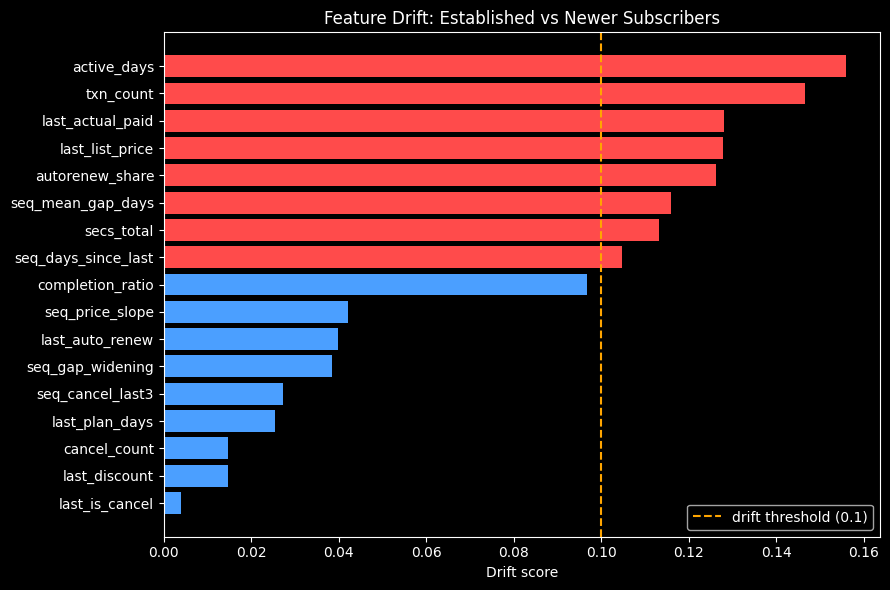

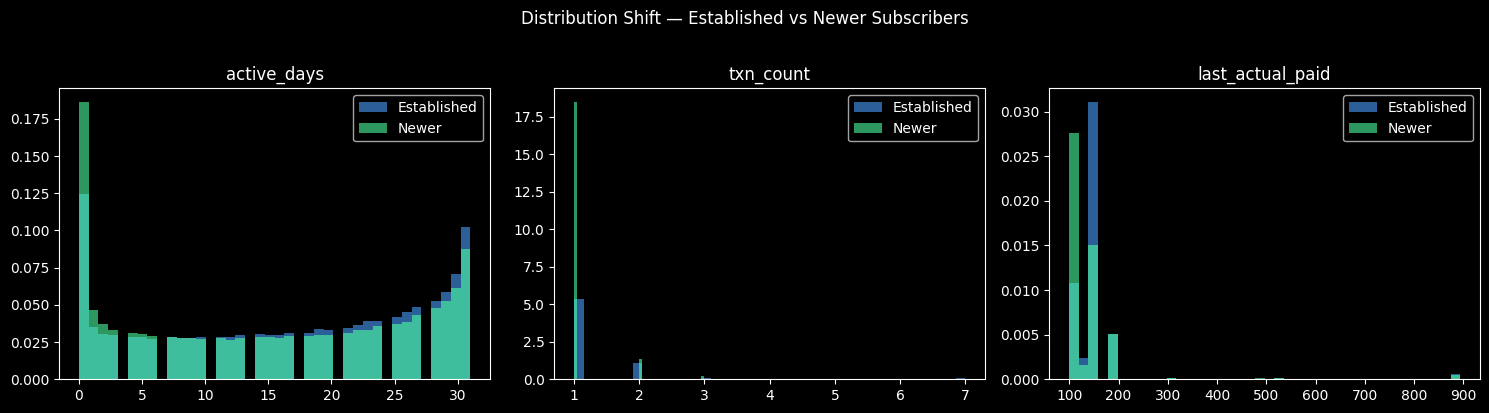

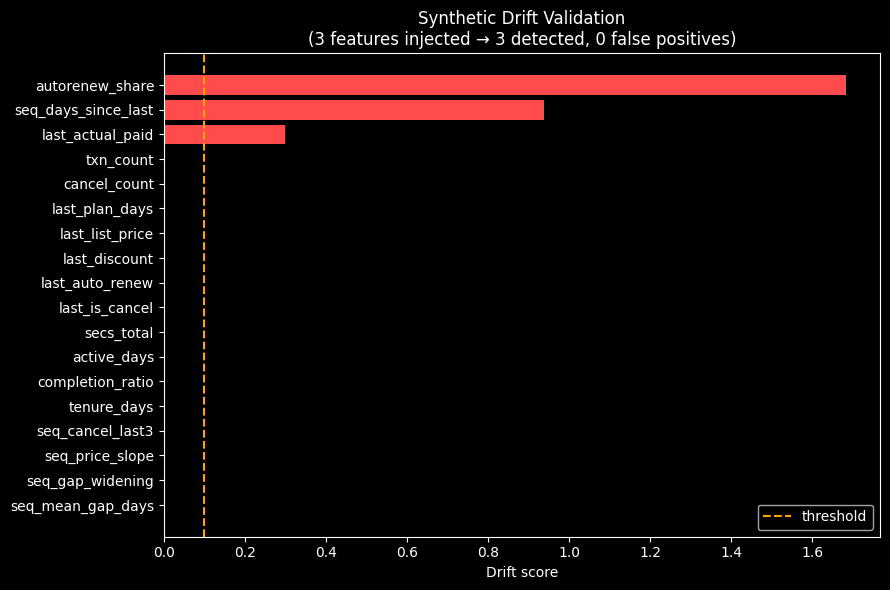

✅ Saved 3 drift figures to reports/figures/


In [16]:
# Drift visualizations from real results
import matplotlib.pyplot as plt
import numpy as np, json, os
os.makedirs(f"{PROJECT}/reports/figures", exist_ok=True)
plt.style.use("dark_background")  # matches your dark UI

# --- 1. Drift-score ranking bar chart (temporal) ---
feats = [(f["feature"], f["drift_score"]) for f in temporal["drifted_features"]
         if f["feature"] != "tenure_days"]  # exclude the artifact
feats.sort(key=lambda x: x[1], reverse=True)
names = [f[0] for f in feats]; scores = [f[1] for f in feats]
colors = ["#ff4b4b" if s > 0.1 else "#4b9fff" for s in scores]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(names[::-1], scores[::-1], color=colors[::-1])
ax.axvline(0.1, color="#ffa500", linestyle="--", label="drift threshold (0.1)")
ax.set_xlabel("Drift score"); ax.set_title("Feature Drift: Established vs Newer Subscribers")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/drift_ranking.png", dpi=120, bbox_inches="tight")
plt.show()

# --- 2. Overlaid distributions for top 3 drifted features ---
top3 = [n for n in names[:3]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top3):
    ref = reference[feat].clip(reference[feat].quantile(0.01), reference[feat].quantile(0.99))
    cur = current[feat].clip(current[feat].quantile(0.01), current[feat].quantile(0.99))
    ax.hist(ref, bins=40, alpha=0.6, label="Established", color="#4b9fff", density=True)
    ax.hist(cur, bins=40, alpha=0.6, label="Newer", color="#4bff9f", density=True)
    ax.set_title(f"{feat}"); ax.legend()
fig.suptitle("Distribution Shift — Established vs Newer Subscribers", y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/drift_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

# --- 3. Synthetic validation: injected vs detected ---
syn_feats = [(f["feature"].split(",")[0], f["drift_score"]) for f in synthetic["drifted_features"]]
syn_feats.sort(key=lambda x: x[1], reverse=True)
sn = [f[0] for f in syn_feats]; ss = [f[1] for f in syn_feats]
sc = ["#ff4b4b" if s > 0.1 else "#333333" for s in ss]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sn[::-1], ss[::-1], color=sc[::-1])
ax.axvline(0.1, color="#ffa500", linestyle="--", label="threshold")
ax.set_xlabel("Drift score"); ax.set_title("Synthetic Drift Validation\n(3 features injected → 3 detected, 0 false positives)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT}/reports/figures/drift_synthetic.png", dpi=120, bbox_inches="tight")
plt.show()

print("✅ Saved 3 drift figures to reports/figures/")

## Summary — Drift Monitoring (MLOps)

Production ML models degrade when incoming data drifts from what they were trained on. This notebook implements drift detection with **Evidently** and validates that the pipeline works.

**Why it matters.** A churn model trained on 2017 subscribers will silently lose accuracy if the subscriber base evolves (new acquisition channels, pricing changes, engagement shifts). Drift monitoring flags this *before* it shows up as degraded predictions, triggering retraining.

**1. Temporal drift (real).** Split users into established vs newer cohorts (by tenure) and compared feature distributions. **9 of 18 features drifted** (Wasserstein / Jensen-Shannon distance, threshold 0.1). Excluding `tenure_days` (an expected artifact of the cohort definition), **8 behavioral and pricing features genuinely shifted**: `txn_count`, `autorenew_share`, `last_actual_paid`, `last_list_price`, `secs_total`, `active_days`, `seq_days_since_last`, `seq_mean_gap_days`.

**Business read:** newer subscribers differ from the established base in engagement, pricing, and transaction cadence — a real signal that the model should be monitored and periodically retrained as the user mix evolves.

**2. Synthetic drift (pipeline validation).** Injected known shifts into 3 features (`autorenew_share` ×0.5, `last_actual_paid` ×1.3, `seq_days_since_last` +45) and confirmed detection. **Evidently flagged exactly those 3 (scores 1.68, 0.30, 0.94) and left all 15 untouched features at 0.0** — precise detection, zero false positives. This proves the monitoring catches deliberate drift, not just that it runs.

**Honest note:** `tenure_days` drift in the temporal report is expected (we split on tenure); the meaningful signals are the behavioral/pricing features. Temporal cohort comparison is used as a proxy for production drift since the dataset is a single static snapshot — documented as such.

**Artifacts:** `reports/drift/temporal_drift.html` (interactive report), `synthetic_drift.html` (validation report), `drift_summary.json` (headline metrics for the dashboard).